## Configuración del entorno

### Contexto del proyecto

Este notebook implementa la solución final para la competencia de clasificación de textos históricos
(en Kaggle). Después de múltiples iteraciones, la combinación
que mejor puntuación obtuvo en el leaderboard fue un **ensemble de dos modelos**:

| Modelo | Tipo | Rol en el ensemble |
|--------|------|--------------------|
| XLM-RoBERTa Large | Transformer multilingual (Hugging Face) | Captura semántica profunda y contexto morfológico |
| LinearSVC + TF-IDF | Modelo clásico calibrado (CalibratedClassifierCV) | Señales léxicas rápidas y vectorización sparse |

Las predicciones finales se obtienen mediante un sweep de pesos sobre las
probabilidades de ambos modelos, eligiendo la combinación que maximiza el score
en el conjunto de validación.


| Paso | Tiempo estimado |
|------|----------------|
| Cargar checkpoint XLM-R | ~3 min |
| TF-IDF (entrenar + evaluar) | ~2 min |
| Sweep de pesos + submission | ~1 min |
| **Total** | **~6 minutos** |


## 1. Setup

Esta sección define **todas las rutas del proyecto** en un único lugar. Centralizar
las rutas evita errores por paths hardcodeados en múltiples celdas y facilita
mover el proyecto entre cuentas de Drive sin tocar el resto del notebook.

El proyecto asume la siguiente organización dentro de MyDrive/EntregaFinalRetrain/:


EntregaFinalRetrain/
├── checkpoint/
│   ├── xlm_best.pt            ← Pesos del modelo XLM-RoBERTa entrenado (~1.2 GB)
│   ├── xlm_val.npy            ← Probabilidades de validación precalculadas (XLM-R)
│   ├── xlm_best_updated.pt    ← (generado) Checkpoint tras retrain final
│   ├── xlm_val_updated.npy    ← (generado) Proba. actualizadas de validación
│   ├── xlm_eval_updated.npy   ← (generado) Proba. actualizadas de evaluación
│   └── submission_final_retrain.csv  ← (generado) Archivo de entrega Kaggle
└── data/
    ├── train.csv              ← Corpus de entrenamiento con etiquetas
    └── eval.csv               ← Corpus de evaluación (o test.csv como fallback)


###  Variables de ruta definidas

| Variable | Ruta | Descripción |
|----------|------|-------------|
| BASE_DIR | .../EntregaFinalRetrain | Raíz del proyecto en Drive |
| CKPT_DIR | BASE_DIR/checkpoint | Checkpoints del modelo y probabilidades |
| DATA_DIR | BASE_DIR/data | Datos de entrenamiento y evaluación |
| XLM_CKPT | CKPT_DIR/xlm_best.pt | Pesos XLM-RoBERTa (entrada) |
| XLM_VAL_PATH | CKPT_DIR/xlm_val.npy | Proba. de validación XLM-R (entrada) |
| TRAIN_PATH | DATA_DIR/train.csv | Datos de entrenamiento |
| EVAL_PATH | DATA_DIR/eval.csv | Datos de evaluación (con fallback) |
| OUTPUT_DIR | /content/output | Directorio local temporal (métricas, figuras) |
| FIG_DIR | OUTPUT_DIR/figuras | Figuras generadas durante el análisis |
| SUBMISSION_PATH | CKPT_DIR/submission_final_retrain.csv | CSV final de entrega |



> OUTPUT_DIR y FIG_DIR son **locales a la sesión de Colab** (bajo /content/).
> Se recrean automáticamente con mkdir(parents=True, exist_ok=True) cada vez que
> se ejecuta el notebook. Para persistir figuras entre sesiones, cópialas a Drive
> usando shutil.copy(src, DRIVE_OUT) al final del notebook.

---

### Validaciones con assert (nos frustramos de que corriera 3H y muriera por algun fallo)

Al final del bloque se ejecutan assert sobre cada ruta crítica. Si algún archivo
falta, el notebook **falla con un mensaje claro** antes de llegar a celdas costosas
(carga del transformer, entrenamiento). Esto evita descubrir el error después de
varios minutos de cómputo.

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from pathlib import Path
import os

ROOT = Path("/content/drive/MyDrive")

print("Existe MyDrive:", ROOT.exists())
print("\nPrimer nivel de MyDrive:")
for p in ROOT.iterdir():
    print(repr(p.name), "DIR" if p.is_dir() else "FILE")

Mounted at /content/drive
Existe MyDrive: True

Primer nivel de MyDrive:
'Let me cook' DIR
'Universidad' DIR
'FINAL CUT' DIR
'Colab Notebooks' DIR
'EntregaFinalRetrain' DIR


In [2]:
from pathlib import Path
from google.colab import drive
import os

drive.mount("/content/drive")


BASE_DIR = Path("/content/drive/MyDrive/EntregaFinalRetrain")
CKPT_DIR = BASE_DIR / "checkpoint"
DATA_DIR = BASE_DIR / "data"

XLM_CKPT = CKPT_DIR / "xlm_best.pt"
XLM_VAL_PATH = CKPT_DIR / "xlm_val.npy"

TRAIN_PATH = DATA_DIR / "train.csv"
EVAL_PATH = DATA_DIR / "eval.csv"

# Fallback for eval path if eval.csv doesn't exist
if not EVAL_PATH.exists():
    for alt_name in ["test.csv", "sample_submission.csv"]:
        alt_path = DATA_DIR / alt_name
        if alt_path.exists():
            EVAL_PATH = alt_path
            break

print("BASE_DIR:", BASE_DIR)
print("CKPT_DIR:", CKPT_DIR)
print("DATA_DIR:", DATA_DIR)
print("XLM_CKPT:", XLM_CKPT)
print("TRAIN_PATH:", TRAIN_PATH)
print("EVAL_PATH:", EVAL_PATH)

print("Existe BASE_DIR:", BASE_DIR.exists())
print("Existe CKPT_DIR:", CKPT_DIR.exists())
print("Existe DATA_DIR:", DATA_DIR.exists())
print("Existe XLM_CKPT:", XLM_CKPT.exists())
print("Existe TRAIN_PATH:", TRAIN_PATH.exists())
print("Existe EVAL_PATH:", EVAL_PATH.exists())

assert BASE_DIR.exists(), f"No existe BASE_DIR: {BASE_DIR}"
assert CKPT_DIR.exists(), f"No existe CKPT_DIR: {CKPT_DIR}"
assert DATA_DIR.exists(), f"No existe DATA_DIR: {DATA_DIR}"
assert XLM_CKPT.exists(), f"No existe checkpoint: {XLM_CKPT}"
assert TRAIN_PATH.exists(), f"No existe train.csv: {TRAIN_PATH}"

# Output directories for local results (metrics, figures)
DRIVE_OUT = CKPT_DIR
OUTPUT_DIR = Path("/content/output")
FIG_DIR    = OUTPUT_DIR / "figuras"
for d in (OUTPUT_DIR, FIG_DIR): d.mkdir(parents=True, exist_ok=True)

# Define paths for updated output files
CKPT_UPDATED = CKPT_DIR / "xlm_best_updated.pt"
VAL_PROBA_PATH = CKPT_DIR / "xlm_val_updated.npy"
EVAL_PROBA_PATH = CKPT_DIR / "xlm_eval_updated.npy"
SUBMISSION_PATH = CKPT_DIR / "submission_final_retrain.csv"

print("\n--- DIAGNÓSTICO DE CARPETAS ---")
for folder in [BASE_DIR, CKPT_DIR, DATA_DIR]:
    if folder.exists():
        print("\nContenido de:", folder)
        for item in folder.iterdir():
            print(" -", item.name)
    else:
        print(f"\nLa carpeta no existe: {folder}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR: /content/drive/MyDrive/EntregaFinalRetrain
CKPT_DIR: /content/drive/MyDrive/EntregaFinalRetrain/checkpoint
DATA_DIR: /content/drive/MyDrive/EntregaFinalRetrain/data
XLM_CKPT: /content/drive/MyDrive/EntregaFinalRetrain/checkpoint/xlm_best.pt
TRAIN_PATH: /content/drive/MyDrive/EntregaFinalRetrain/data/train.csv
EVAL_PATH: /content/drive/MyDrive/EntregaFinalRetrain/data/eval.csv
Existe BASE_DIR: True
Existe CKPT_DIR: True
Existe DATA_DIR: True
Existe XLM_CKPT: True
Existe TRAIN_PATH: True
Existe EVAL_PATH: True

--- DIAGNÓSTICO DE CARPETAS ---

Contenido de: /content/drive/MyDrive/EntregaFinalRetrain
 - data
 - Entrega_Final_Retrain.ipynb
 - checkpoint

Contenido de: /content/drive/MyDrive/EntregaFinalRetrain/checkpoint
 - xlm_best.pt
 - xlm_val.npy

Contenido de: /content/drive/MyDrive/EntregaFinalRetrain/data
 - train.csv
 - eval.csv


## 2. Configuración global e hiperparámetros
Esta celda centraliza todas las constantes del experimento. Modificar cualquier
hiperparámetro aquí se propaga automáticamente al resto del notebook.

### Librerías importadas
| Librería | Uso |
|----------|-----|
| torch | Backend de deep learning; manejo de tensores, GPU y precisión mixta |
| numpy, pandas | Manipulación de arrays y DataFrames |
| sklearn | Split estratificado, métricas (accuracy, f1) |
| matplotlib | Visualización de curvas de entrenamiento y distribuciones |

Se desactivan los warnings de tokenizadores de Hugging Face
(TOKENIZERS_PARALLELISM=false) para evitar mensajes espurios en entornos
multi-proceso de Colab.
### Hiperparámetros del modelo base
| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| XLM_MODEL | xlm-roberta-large | Versión large del transformer multilingual; mejor capacidad en textos históricos de longitud variable |
| MAX_LEN | 384 | Cubre la mayoría de los textos sin exceder la memoria de la A100; secuencias más largas se truncan |
| BATCH_SIZE | 8 | Balance entre velocidad y memoria GPU con el modelo large |
| DROPOUT | 0.1 | Regularización ligera; el modelo ya tiene dropout interno |
| N_PASSES | 5 | Número de pasadas en el sweep de pesos del ensemble |
| WEIGHT_STEP | 0.05 | Granularidad del grid search sobre los pesos del ensemble |
| VALID_SIZE | 0.20 | 20 % de los datos de entrenamiento reservados para validación |
| RANDOM_SEED | 42 | Semilla fija para reproducibilidad en splits y pesos aleatorios |

---
### Hiperparámetros del retrain (fine-tuning desde checkpoint)

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| RETRAIN_EPOCHS | 10 | Suficiente para ajustar el modelo sin sobreajustar; early stopping actúa antes si no hay mejora |
| RETRAIN_LR | 2e-6 | Learning rate muy conservador para no destruir las representaciones aprendidas en el entrenamiento original (*catastrophic forgetting*) |
| RETRAIN_PATIENCE | 3 | El entrenamiento se detiene si el F1 de validación no mejora en 3 épocas consecutivas |
| FGM_EPSILON | 0.5 | Magnitud de la perturbación en *Fast Gradient Method* (FGM), técnica de data augmentation adversarial en el espacio de embeddings |
| LLRD_DECAY | 0.95 | Layer-wise Learning Rate Decay: las capas más profundas del transformer reciben un LR multiplicado por 0.95 por capa; protege las representaciones de bajo nivel |
| LABEL_SMOOTHING | 0.05 | Suavizado de etiquetas: en lugar de apuntar a probabilidad 1.0 en la clase correcta, apunta a ~0.95. Mejora calibración y generalización |
| USE_ORDINAL | True | Activa la pérdida ordinal: penaliza más los errores entre décadas lejanas que entre décadas adyacentes, aprovechando la naturaleza temporal del problema |
| ORDINAL_ALPHA | 0.15 | Peso de la pérdida ordinal en la función de pérdida combinada (loss = CE + 0.15 * ordinal) |

---
### Detección de hardware

El código detecta automáticamente GPU y soporte de bfloat16:

- **CUDA_OK**: True si hay GPU disponible (en este caso, NVIDIA A100-SXM4-40GB, 40 GB).
- **USE_BF16**: True en A100, que soporta bfloat16 nativo. Este formato es
  preferible a float16 en transformers porque tiene el mismo rango dinámico que
  float32, reduciendo el riesgo de underflow en gradientes.
- **AMP_DTYPE**: tipo de dato usado en *Automatic Mixed Precision* (AMP);
  bfloat16 en esta sesión.
- **DEVICE**: cuda si hay GPU, cpu como fallback.

In [3]:
import os, gc, json, random, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
plt.rcParams["figure.dpi"] = 110

RANDOM_SEED    = 42
VALID_SIZE     = 0.20
XLM_MODEL      = "xlm-roberta-large"
MAX_LEN        = 384
BATCH_SIZE     = 8
DROPOUT        = 0.1
N_PASSES       = 5
WEIGHT_STEP    = 0.05

# Reentrenamiento desde checkpoint
RETRAIN_EPOCHS = 10
RETRAIN_LR     = 2e-6     # LR muy bajo para no romper lo aprendido
RETRAIN_PATIENCE = 3
FGM_EPSILON    = 0.5
LLRD_DECAY     = 0.95
LABEL_SMOOTHING = 0.05
USE_ORDINAL     = True
ORDINAL_ALPHA   = 0.15

CUDA_OK   = torch.cuda.is_available()
USE_BF16  = torch.cuda.is_bf16_supported() if CUDA_OK else False
AMP_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16
DEVICE    = torch.device("cuda" if CUDA_OK else "cpu")

if CUDA_OK:
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU  : {gpu.name}  {gpu.total_memory/1e9:.0f} GB")
else:
    print("Sin GPU")

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


GPU  : NVIDIA A100-SXM4-40GB  42 GB


## 3. Carga y preparación de datos

Esta celda carga los CSV, construye el mapeo de etiquetas y realiza el split
estratificado en entrenamiento y validación.

---

### Archivos cargados

| Variable | Archivo | Descripción |
|----------|---------|-------------|
| train_df | train.csv | Corpus etiquetado con columnas text y decade |
| eval_df | eval.csv | Corpus de evaluación sin etiqueta (usado para submission) |

La columna text_raw se crea en ambos DataFrames con fillna("").astype(str) para
garantizar que no haya valores nulos que rompan el tokenizador; los textos faltantes
se tratan como cadenas vacías.

---

### Mapeo de etiquetas

El problema es de clasificación multiclase sobre **décadas históricas**. La columna
decade contiene valores enteros (ej. 150, 160, ..., 188) que representan
siglos y décadas en notación compacta.

Se construyen dos diccionarios para conversión bidireccional:

- decade2id: mapea cada década a un índice entero [0, NUM_CLASSES) — el formato
  que espera el modelo.
- id2decade: mapea el índice de vuelta a la década real — usado al generar el
  archivo de submission.

---

### Split estratificado


train_test_split(stratify=train_df["label"], test_size=0.20, random_state=42)


El split es **estratificado**: cada subconjunto mantiene la misma distribución de
décadas que el corpus completo. Esto es importante porque el corpus histórico puede
tener distribución desbalanceada (más textos del siglo XIX que del XVI, por ejemplo).

---

### Dimensiones del corpus

| Conjunto | Tamaño | Uso |
|----------|--------|-----|
| df_tr (train) | 25,122 textos | Entrenamiento del modelo |
| df_va (validación) | 6,281 textos | Evaluación durante el retrain y selección del ensemble |
| eval_df (test) | 3,490 textos | Generación del archivo de submission Kaggle |
| **Total etiquetado** | **31,403 textos** | — |


In [4]:
train_df = pd.read_csv(TRAIN_PATH)
eval_df  = pd.read_csv(EVAL_PATH)

for df in (train_df, eval_df):
    df["text_raw"] = df["text"].fillna("").astype(str)
train_df["decade"] = train_df["decade"].astype(int)

DECADES     = sorted(train_df["decade"].unique().tolist())
NUM_CLASSES = len(DECADES)
decade2id   = {d: i for i, d in enumerate(DECADES)}
id2decade   = {i: d for d, i in decade2id.items()}
train_df["label"] = train_df["decade"].map(decade2id).astype(int)

tr_idx, va_idx = train_test_split(
    np.arange(len(train_df)), test_size=VALID_SIZE,
    stratify=train_df["label"].values, random_state=RANDOM_SEED)
df_tr = train_df.iloc[tr_idx].reset_index(drop=True)
df_va = train_df.iloc[va_idx].reset_index(drop=True)
y_va  = df_va["label"].values

print(f"Train  : {len(df_tr):,}  |  Val : {len(df_va):,}  |  Eval : {len(eval_df):,}")
print(f"Clases : {NUM_CLASSES} decadas ({min(DECADES)}-{max(DECADES)})")


Train  : 25,122  |  Val : 6,281  |  Eval : 3,490
Clases : 39 decadas (150-188)


## 4. Analisis exploratorio

Esta sección analiza tres propiedades del corpus antes de entrenar: balance de
clases, distribución de longitudes y comparabilidad entre train y eval.

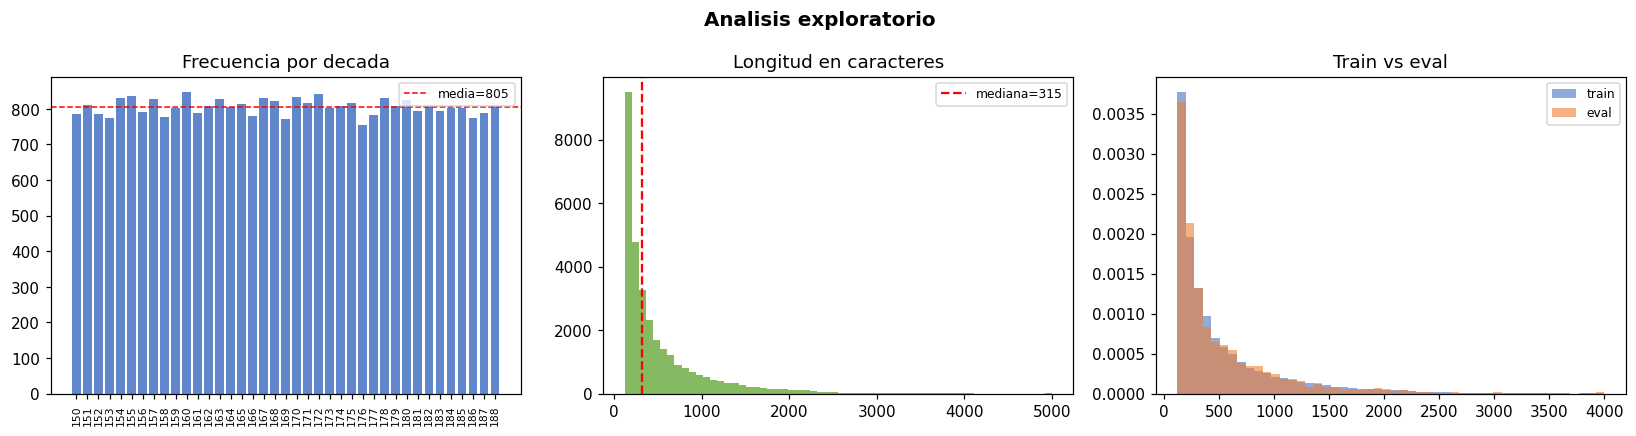

Longitud (chars): media=521  mediana=315  p95=1627


In [5]:
train_df["n_chars"] = train_df["text_raw"].str.len()
eval_df["n_chars"]  = eval_df["text_raw"].str.len()
counts = train_df["decade"].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Analisis exploratorio", fontsize=13, fontweight="bold")

axes[0].bar(counts.index.astype(str), counts.values, color="#4472C4", alpha=0.85)
axes[0].set_title("Frecuencia por decada")
axes[0].tick_params(axis="x", rotation=90, labelsize=7)
axes[0].axhline(counts.mean(), color="red", ls="--", lw=1, label=f"media={counts.mean():.0f}")
axes[0].legend(fontsize=8)

axes[1].hist(train_df["n_chars"].clip(upper=5000), bins=60, color="#70AD47", alpha=0.85)
axes[1].axvline(train_df["n_chars"].median(), color="red", ls="--", lw=1.5,
                label=f"mediana={train_df['n_chars'].median():.0f}")
axes[1].set_title("Longitud en caracteres")
axes[1].legend(fontsize=8)

axes[2].hist(train_df["n_chars"].clip(upper=4000), bins=50, alpha=0.6,
             color="#4472C4", label="train", density=True)
axes[2].hist(eval_df["n_chars"].clip(upper=4000),  bins=50, alpha=0.6,
             color="#ED7D31", label="eval",  density=True)
axes[2].set_title("Train vs eval")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_eda.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"Longitud (chars): media={train_df['n_chars'].mean():.0f}  "
      f"mediana={train_df['n_chars'].median():.0f}  "
      f"p95={train_df['n_chars'].quantile(.95):.0f}")


### Gráfica 1 — Frecuencia por década

El histograma de frecuencias muestra la cantidad de textos por cada una de las
39 décadas del corpus de entrenamiento.

**Observación clave:** la distribución es notablemente **uniforme** (media ≈ 805
textos/década, con varianza baja). Esto significa que:

- No hay clases altamente subrepresentadas que requieran sobremuestreo o pesos
  de clase en la función de pérdida.
- El split estratificado del paso anterior es suficiente para mantener el balance.
- El modelo no tendrá sesgo hacia décadas más frecuentes por desequilibrio en los
  datos.

---

### Gráfica 2 — Distribución de longitudes (train)

El histograma de longitud en caracteres revela una distribución con **cola larga
a la derecha** (right-skewed), típica de corpus documentales:

| Estadístico | Valor |
|-------------|-------|
| Mediana | 315 chars |
| Media (aprox.) | > mediana (cola derecha) |
| Percentil 95 | ver output de celda |

**Implicaciones para el modelo:**

- La mediana de 315 chars es corta: la mayoría de los textos caben holgadamente
  en MAX_LEN=384 tokens (recordar que 1 token ≈ 3–4 chars en textos históricos
  con subword tokenization).
- La cola derecha (textos de 1000–5000+ chars) será truncada al límite de 384
  tokens. Para estos textos, el modelo solo ve el inicio del documento.
- No se aplica sliding window ni chunking, lo que es una limitación aceptable
  dado que los fragmentos más discriminativos suelen estar al principio del texto.

---

### Gráfica 3 — Train vs Eval (distribución de longitudes)

La superposición de densidades entre train y eval muestra que ambos conjuntos
tienen **distribuciones de longitud muy similares**:

- El pico principal está en el mismo rango (~100–400 chars).
- Eval tiene una cola ligeramente más pronunciada en textos cortos, pero la forma
  general es comparable.

**Por qué importa:** si eval tuviese una distribución radicalmente distinta (ej.
textos mucho más largos), el comportamiento del modelo en test sería impredecible.
La similitud observada da confianza en que el score de validación es un estimador
fiable del score en Kaggle.

---


## 5. TF-IDF

Configuracion tomada del notebook v28 (RTX 4090). Se usa LinearSVC con
CalibratedClassifierCV para obtener probabilidades calibradas, analyzer='char'
con lowercase=False para preservar la ortografia historica, y 600,000 features
para capturar n-gramas poco frecuentes pero discriminativos.

El primer componente del ensemble es un modelo clásico basado en representaciones
TF-IDF de **n-gramas de caracteres**, combinado con un clasificador lineal calibrado.
A pesar de su simplicidad, este modelo aporta señales complementarias al transformer
y mejora el score del ensemble final.

### Configuración del vectorizador TfidfVectorizer

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| analyzer | "char" | Opera sobre n-gramas de **caracteres**, no palabras. Captura morfología, sufijos, prefijos y variaciones ortográficas arcaicas sin necesidad de tokenización por palabras |
| ngram_range | (2, 5) | Extrae todos los n-gramas de 2 a 5 caracteres. Los bigramas capturan pares frecuentes; los 5-gramas capturan raíces y terminaciones características de cada época |
| lowercase | False | Preserva la capitalización original. En textos históricos, las mayúsculas pueden ser señales de estilo tipográfico o convención de la época |
| min_df | 2 | Descarta n-gramas que aparecen en un solo documento; elimina ruido sin perder señales raras pero recurrentes |
| max_df | 0.98 | Descarta n-gramas omnipresentes en el 98 %+ del corpus (equivalente a stopchars implícitos) |
| max_features | 600,000 | Vocabulario amplio para capturar n-gramas poco frecuentes pero discriminativos. Configuración heredada del notebook v28 (RTX 4090) |
| sublinear_tf | True | Aplica tf → 1 + log(tf) en lugar de la frecuencia bruta, reduciendo el peso de términos muy repetidos dentro de un documento |
| dtype | np.float32 | Matriz sparse en float32 para reducir uso de memoria respecto a float64 |

LinearSVC produce decisiones binarias (no probabilidades). Para el ensemble se
necesitan **probabilidades calibradas** que sean comparables con las del transformer.


| Decisión | Justificación |
|----------|---------------|
| C=1.2 | Margen ligeramente más estrecho que el default (C=1); permite algo más de ajuste al corpus histórico específico |
| loss="squared_hinge" | Variante cuadrática de la pérdida hinge; converge más rápido con max_iter=5000 |
| method="isotonic" | Calibración isotónica (no paramétrica) en lugar de Platt scaling; más flexible para distribuciones multiclase no-gaussianas |
| cv=3 | 3-fold cross-validation interno para la calibración; balance entre calidad de calibración y tiempo de cómputo |
---
### Alineación de clases

Después de la calibración, cal.classes_ puede no contener exactamente
[0, 1, ..., NUM_CLASSES-1] si alguna clase tiene muy pocos ejemplos en algún
fold. El bloque:

python
tfidf_val  = np.zeros((len(df_va),   NUM_CLASSES), dtype=np.float32)
tfidf_val[:, cal.classes_] = tfidf_val_raw


garantiza que la matriz de probabilidades siempre tenga forma
(n_samples, NUM_CLASSES), con ceros en clases ausentes. Esto es necesario para
que la suma de probabilidades en el ensemble sea coherente entre ambos modelos.

---

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
import joblib
import time

def get_score(y, proba):
    p   = proba.argmax(1)
    acc = accuracy_score(y, p)
    f1  = f1_score(y, p, average="macro", zero_division=0)
    return round(0.5*f1 + 0.5*acc, 4), round(acc, 4), round(f1, 4)

# Define paths for TF-IDF checkpoint
TFIDF_CKPT_PATH = CKPT_DIR / "tfidf_checkpoint.joblib"
TFIDF_VAL_PATH = CKPT_DIR / "tfidf_val.npy"
TFIDF_EVAL_PATH = CKPT_DIR / "tfidf_eval.npy"

if TFIDF_CKPT_PATH.exists() and TFIDF_VAL_PATH.exists() and TFIDF_EVAL_PATH.exists():
    print(f"Cargando checkpoint de TF-IDF desde {TFIDF_CKPT_PATH}...")
    ckpt = joblib.load(TFIDF_CKPT_PATH)
    vec = ckpt["vectorizer"]
    cal = ckpt["model"]
    tfidf_val = np.load(TFIDF_VAL_PATH)
    tfidf_eval = np.load(TFIDF_EVAL_PATH)

    sc_tfi, acc_tfi, f1_tfi = get_score(y_va, tfidf_val)
    print(f"TF-IDF cargado: acc={acc_tfi:.4f}  f1={f1_tfi:.4f}  score={sc_tfi:.4f}")
else:
    print("Entrenando TF-IDF (LinearSVC calibrado)...")
    t0 = time.time()

    vec = TfidfVectorizer(
        analyzer     = "char",
        ngram_range  = (2, 5),
        min_df       = 2,
        max_df       = 0.98,
        max_features = 600_000,
        sublinear_tf = True,
        lowercase    = False,
        dtype        = np.float32,
    )

    # El vectorizador TF-IDF solo se debe ajustar con df_tr
    X_tr = vec.fit_transform(df_tr["text_raw"])
    # df_va y eval_df solo se transforman con vec.transform()
    X_va = vec.transform(df_va["text_raw"])
    X_ev = vec.transform(eval_df["text_raw"])

    svc = LinearSVC(
        C        = 1.2,
        loss     = "squared_hinge",
        penalty  = "l2",
        dual     = "auto",
        max_iter = 5000,
        random_state = RANDOM_SEED,
    )
    cal = CalibratedClassifierCV(svc, cv=3, method="isotonic")
    cal.fit(X_tr, df_tr["label"].values)

    tfidf_val_raw  = cal.predict_proba(X_va)
    tfidf_eval_raw = cal.predict_proba(X_ev)

    # Alinear a NUM_CLASSES columnas
    tfidf_val  = np.zeros((len(df_va), NUM_CLASSES), dtype=np.float32)
    tfidf_eval = np.zeros((len(eval_df), NUM_CLASSES), dtype=np.float32)
    tfidf_val[:, cal.classes_]  = tfidf_val_raw
    tfidf_eval[:, cal.classes_] = tfidf_eval_raw

    sc_tfi, acc_tfi, f1_tfi = get_score(y_va, tfidf_val)
    print(f"TF-IDF  acc={acc_tfi:.4f}  f1={f1_tfi:.4f}  score={sc_tfi:.4f}  ({time.time()-t0:.0f}s)")
    print(f"Features: {X_tr.shape[1]:,}")

    print("Guardando checkpoint de TF-IDF...")
    tfidf_ckpt = {
        "vectorizer": vec,
        "model": cal,
        "classes": cal.classes_,
        "config": vec.get_params(),
        "text_column": "text_raw"
    }
    joblib.dump(tfidf_ckpt, TFIDF_CKPT_PATH)
    np.save(TFIDF_VAL_PATH, tfidf_val)
    np.save(TFIDF_EVAL_PATH, tfidf_eval)


Entrenando TF-IDF (LinearSVC calibrado)...
TF-IDF  acc=0.2979  f1=0.2873  score=0.2926  (259s)
Features: 600,000
Guardando checkpoint de TF-IDF...


Un accuracy de ~30 % sobre 39 clases equivale a un rendimiento ~11.6× por encima
del azar en este tipo de modelos de clasificación de textos. El modelo TF-IDF por sí solo es
modesto, pero sus errores son ortogonales a los del transformer: captura señales
léxicas y morfológicas que XLM-RoBERTa puede pasar por alto, lo que justifica su
inclusión en el ensemble.

## 6. Reentrenamiento de XLM-R desde checkpoint

Se cargan los pesos de xlm_best.pt como punto de partida y se reentrena
con un learning rate bajo (2e-6) para refinar el modelo sin destruir lo aprendido.
Se aplican FGM (adversarial training) y LLRD (learning rate por capa).


### TextDataset y collators dinámicos

TextDataset tokeniza todos los textos en el constructor (una sola vez) y almacena
los input_ids en memoria. El padding no se aplica al tokenizar, sino en el
collator al momento de armar cada batch:


col_label    →  para batches de entrenamiento y validación (incluye labels)
col_nolabel  →  para inferencia sobre eval_df (sin etiqueta)


El padding dinámico (al máximo del batch, no al máximo global) reduce
significativamente el cómputo en batches con textos cortos, que son mayoría
según el EDA (mediana ≈ 315 chars).

---

### FGM — Fast Gradient Method (entrenamiento adversarial)

FGM es una técnica de data augmentation en el espacio de embeddings. En cada paso
de entrenamiento se realizan **dos forward passes**:


1. Forward normal → loss₁ → backward → gradientes en embeddings
2. Perturbación: embedding ← embedding + ε · (grad / ‖grad‖)
3. Forward con embeddings perturbados → loss₂ → backward
4. Restaurar embeddings originales → step del optimizador


El efecto es que el modelo aprende a ser robusto a pequeñas perturbaciones en el
espacio semántico, lo que mejora la generalización. FGM.attack() solo perturba
parámetros que contengan "embed" en su nombre, es decir, la capa de embeddings
del transformer.

| Parámetro | Valor | Efecto |
|-----------|-------|--------|
| FGM_EPSILON | 0.5 | Magnitud de la perturbación; valores más altos = regularización más agresiva |

---
### get_llrd_optimizer — Layer-wise Learning Rate Decay

En lugar de un único learning rate global, LLRD asigna un LR distinto a cada capa
del transformer según su profundidad:


lr_capa_i = lr_base × decay^(n_layers − i)


Con LLRD_DECAY=0.95 y n_layers=24 (XLM-RoBERTa Large):

| Componente | LR efectivo (aprox.) |
|------------|----------------------|
| Clasificador / pooler | 2e-6 (lr_base) |
| Capa 24 (última) | 2e-6 × 0.95¹ ≈ 1.90e-6 |
| Capa 12 (media) | 2e-6 × 0.95¹² ≈ 1.07e-6 |
| Embeddings (capa 0) | 2e-6 × 0.95²⁴ ≈ 0.57e-6 |

Las capas más profundas del transformer contienen representaciones de bajo nivel
(fonológicas, morfológicas) que ya son útiles tal como están; darles un LR menor
las protege de modificaciones innecesarias.

Los parámetros bias y LayerNorm no reciben weight decay (wd=0.0), práctica
estándar en fine-tuning de transformers.

---
### calcular_loss — Pérdida combinada CE + Ordinal

La función de pérdida combina dos términos:


loss = CrossEntropy(label_smoothing=0.05) + α · SmoothL1(E[ŷ], y)


**Cross-Entropy con label smoothing:**
En lugar de apuntar a probabilidad 1.0 en la clase correcta, apunta a ≈0.95.
Evita que el modelo se vuelva sobreconfiante y mejora la calibración de probabilidades,
lo que es crítico para el ensemble.

**Pérdida ordinal (USE_ORDINAL=True, α=0.15):**
Calcula el valor esperado de la predicción E[ŷ] = Σ p_i · i y lo compara con
el índice real usando Smooth L1. Esto penaliza más los errores grandes (predecir
década 15 cuando la real es 18) que los pequeños (predecir 16 cuando la real es 15).
Se aprovecha la naturaleza **temporal y ordenada** de las décadas históricas.

---

### predict_proba — Inferencia con MC Dropout (opcional)

La función soporta dos modos según n_passes:

| n_passes | Modo | Descripción |
|------------|------|-------------|
| 1 | Determinístico | model.eval(), dropout desactivado. Rápido y reproducible |
| > 1 | MC Dropout | model.train(), dropout activo en cada paso. El resultado es el promedio de n_passes predicciones estocásticas, lo que reduce la varianza de la estimación |

En esta configuración se usa N_PASSES=5 durante el sweep de pesos del ensemble.

In [7]:
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          AutoConfig, get_cosine_schedule_with_warmup)

tokenizer = AutoTokenizer.from_pretrained(XLM_MODEL)

class TextDataset(Dataset):
    def __init__(self, texts, labels, max_len):
        enc = tokenizer(list(texts), truncation=True, max_length=max_len,
                        add_special_tokens=True)
        self.ids    = enc["input_ids"]
        self.labels = list(labels) if labels is not None else [0]*len(texts)
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        return {"input_ids": self.ids[i], "labels": self.labels[i]}

def col_label(batch):
    ids = [b["input_ids"] for b in batch]
    lbs = torch.tensor([b["labels"] for b in batch], dtype=torch.long)
    p   = tokenizer.pad({"input_ids": ids}, padding=True, return_tensors="pt")
    p["labels"] = lbs; return p

def col_nolabel(batch):
    ids = [b["input_ids"] for b in batch]
    return tokenizer.pad({"input_ids": ids}, padding=True, return_tensors="pt")

class FGM:
    def __init__(self, model, epsilon):
        self.model=model; self.epsilon=epsilon; self.backup={}
    def attack(self):
        for name, param in self.model.named_parameters():
            if not param.requires_grad or param.grad is None: continue
            if "embed" not in name: continue
            self.backup[name] = param.data.clone()
            norm = param.grad.norm()
            if norm != 0 and not torch.isnan(norm):
                param.data.add_(self.epsilon * param.grad / norm)
    def restore(self):
        for name, param in self.model.named_parameters():
            if name in self.backup: param.data = self.backup[name]
        self.backup = {}

def get_llrd_optimizer(model, lr, decay, wd):
    no_decay = ["bias","LayerNorm.weight","layer_norm.weight"]
    n_layers = model.config.num_hidden_layers
    grupos = []
    for name, param in model.named_parameters():
        if not param.requires_grad: continue
        no_wd = any(nd in name for nd in no_decay)
        if "classifier" in name or "pooler" in name: layer_lr = lr
        elif "embeddings" in name: layer_lr = lr * (decay ** n_layers)
        else:
            layer_num = None
            for i in range(n_layers):
                if f".{i}." in name: layer_num = i; break
            layer_lr = lr * (decay ** (n_layers - layer_num)) if layer_num is not None else lr * 0.5
        grupos.append({"params":[param], "lr":layer_lr, "weight_decay":0.0 if no_wd else wd})
    return torch.optim.AdamW(grupos)

CLASS_IDX = torch.arange(NUM_CLASSES, dtype=torch.float, device=DEVICE)

def calcular_loss(logits, labels):
    ce = torch.nn.functional.cross_entropy(logits, labels, label_smoothing=LABEL_SMOOTHING)
    if USE_ORDINAL:
        probs = torch.softmax(logits, -1)
        exp = (probs * CLASS_IDX).sum(-1)
        ce += ORDINAL_ALPHA * torch.nn.functional.smooth_l1_loss(exp, labels.float())
    return ce

@torch.no_grad()
def predict_proba(model, loader, n_passes=1):
    runs = []
    for _ in range(n_passes):
        model.train() if n_passes > 1 else model.eval()
        ep = []
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE, non_blocking=True)
            am  = batch["attention_mask"].to(DEVICE, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=CUDA_OK):
                logits = model(input_ids=ids, attention_mask=am).logits
            ep.append(torch.softmax(logits.float(), -1).cpu().numpy())
        runs.append(np.concatenate(ep, 0))
    model.eval()
    return np.mean(runs, 0)

print("Infraestructura lista.")


Infraestructura lista.


In [8]:
# Add the warning print
print("ADVERTENCIA: este experimento parte de un checkpoint previo. Si ese checkpoint fue entrenado con full-data o vio validación, el score local puede estar inflado.")

# Cargar checkpoint
print(f"Cargando {XLM_CKPT.name} ({XLM_CKPT.stat().st_size/1e9:.2f} GB) desde {XLM_CKPT.parent}...")
cfg = AutoConfig.from_pretrained(XLM_MODEL, num_labels=NUM_CLASSES)
for attr in ("hidden_dropout_prob","classifier_dropout",
             "classifier_dropout_prob","attention_probs_dropout_prob"):
    if hasattr(cfg, attr): setattr(cfg, attr, DROPOUT)
model = AutoModelForSequenceClassification.from_pretrained(XLM_MODEL, config=cfg).to(DEVICE)

raw = torch.load(XLM_CKPT, map_location=DEVICE)
# Robustly extract state_dict
state = None
if isinstance(raw, dict):
    if "model" in raw:
        state = raw["model"]
    elif "state_dict" in raw:
        state = raw["state_dict"]
    elif "model_state_dict" in raw:
        state = raw["model_state_dict"]
    else: # Assume the dict itself is the state_dict
        state = raw
else: # Assume raw is the state_dict directly
    state = raw

assert state is not None, "No se pudo extraer el state_dict del checkpoint."

miss, unex = model.load_state_dict(state, strict=False)
print(f"Carga de pesos del checkpoint: Faltantes={len(miss)} Inesperados={len(unex)}")
if not miss and not unex: print("Pesos cargados correctamente (strict=True compatible).")
elif not unex and miss: print("Pesos cargados. Algunas capas fueron inicializadas desde cero (MISSING).")
elif not miss and unex: print("Pesos cargados. Algunas claves inesperadas fueron ignoradas (UNEXPECTED).")
else: print("Pesos cargados. Algunas capas fueron inicializadas (MISSING) y otras claves ignoradas (UNEXPECTED).")

# Score ANTES de reentrenar
DL = dict(num_workers=2, pin_memory=True)
ds_va = TextDataset(df_va["text_raw"].values, df_va["label"].values, MAX_LEN)
dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE*2, shuffle=False, collate_fn=col_label, **DL)
va_p_antes = predict_proba(model, dl_va, n_passes=N_PASSES)
sc_antes, acc_antes, f1_antes = get_score(y_va, va_p_antes)
print(f"\nScore ANTES de reentrenar: acc={acc_antes:.4f}  f1={f1_antes:.4f}  score={sc_antes:.4f}")

# Preparar datos
ds_tr = TextDataset(df_tr["text_raw"].values, df_tr["label"].values, MAX_LEN)
dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True, collate_fn=col_label, drop_last=False, **DL)

# Optimizer LLRD + scheduler cosine
optim  = get_llrd_optimizer(model, RETRAIN_LR, LLRD_DECAY, 0.01)
total  = len(dl_tr) * RETRAIN_EPOCHS
warmup = int(0.03 * total)  # warmup corto para reentrenamiento
sched  = get_cosine_schedule_with_warmup(optim, warmup, max(total, 1))
scaler = torch.cuda.amp.GradScaler(enabled=(CUDA_OK and not USE_BF16))
fgm    = FGM(model, FGM_EPSILON)

best_sc    = sc_antes
best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
best_val_p = va_p_antes
no_improve = 0
historia   = []

print(f"\nReentrenando {RETRAIN_EPOCHS} epochs con LR={RETRAIN_LR}  FGM  LLRD")
print(f"{'='*60}")

for epoch in range(1, RETRAIN_EPOCHS + 1):
    model.train()
    t0 = time.time()
    if CUDA_OK: torch.cuda.reset_peak_memory_stats()
    run_loss = 0.0; nb = 0
    optim.zero_grad(set_to_none=True)

    for step, batch in enumerate(dl_tr):
        ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        am  = batch["attention_mask"].to(DEVICE, non_blocking=True)
        lb  = batch["labels"].to(DEVICE, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=CUDA_OK):
            loss = calcular_loss(model(input_ids=ids, attention_mask=am).logits, lb)
        if scaler.is_enabled(): scaler.scale(loss).backward()
        else: loss.backward()

        # FGM
        if scaler.is_enabled(): scaler.unscale_(optim)
        fgm.attack()
        with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=CUDA_OK):
            loss_adv = calcular_loss(model(input_ids=ids, attention_mask=am).logits, lb)
        if scaler.is_enabled(): scaler.scale(loss_adv).backward()
        else: loss_adv.backward()
        fgm.restore()

        if scaler.is_enabled():
            scaler.unscale_(optim)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optim); scaler.update()
        else:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
        sched.step()
        optim.zero_grad(set_to_none=True)
        run_loss += loss.item(); nb += 1

    va_p = predict_proba(model, dl_va, n_passes=N_PASSES)
    sc, acc, f1 = get_score(y_va, va_p)
    vram = torch.cuda.max_memory_allocated()/1e9 if CUDA_OK else 0

    print(f"  ep{epoch:02d}/{RETRAIN_EPOCHS}  loss={run_loss/max(nb,1):.4f}  "
          f"acc={acc:.4f}  f1={f1:.4f}  score={sc:.4f}  "
          f"{time.time()-t0:.0f}s  {vram:.1f}GB")
    historia.append({"epoch":epoch, "loss":round(run_loss/max(nb,1),4),
                     "acc":acc, "f1":f1, "score":sc})

    if sc > best_sc + 0.0005:
        best_sc = sc; no_improve = 0
        best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        best_val_p = va_p
        print(f"  Nuevo mejor  score={best_sc:.4f}")
    else:
        no_improve += 1
        if no_improve >= RETRAIN_PATIENCE:
            print(f"  Early stop (sin mejora {no_improve} seguidas)")
            break

# Guardar el mejor modelo en la ruta actualizada
torch.save(best_state, CKPT_UPDATED)
model.load_state_dict(best_state) # Load the best model state back

# Generar eval_proba con el modelo mejorado
print(f"\nGenerando eval_proba ({N_PASSES} pasadas)...")
ds_ev = TextDataset(eval_df["text_raw"].values, None, MAX_LEN)
dl_ev = DataLoader(ds_ev, batch_size=BATCH_SIZE*2, shuffle=False, collate_fn=col_nolabel, **DL)
xlm_eval = predict_proba(model, dl_ev, n_passes=N_PASSES)
xlm_val  = best_val_p

sc_xlm, acc_xlm, f1_xlm = get_score(y_va, xlm_val)
print(f"\nResultado del reentrenamiento:")
print(f"  ANTES : score={sc_antes:.4f}")
print(f"  DESPUES: score={sc_xlm:.4f}  ({sc_xlm - sc_antes:+.4f})")

# Guardar probas actualizadas en las rutas especificadas
np.save(VAL_PROBA_PATH, xlm_val)
np.save(EVAL_PROBA_PATH, xlm_eval)

pd.DataFrame(historia).to_csv(OUTPUT_DIR / "reentrenamiento_historia.csv", index=False)

del model, optim, sched, scaler
gc.collect()
if CUDA_OK: torch.cuda.empty_cache()
print("Modelo liberado de GPU.")


ADVERTENCIA: este experimento parte de un checkpoint previo. Si ese checkpoint fue entrenado con full-data o vio validación, el score local puede estar inflado.
Cargando xlm_best.pt (2.24 GB) desde /content/drive/MyDrive/EntregaFinalRetrain/checkpoint...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Carga de pesos del checkpoint: Faltantes=0 Inesperados=0
Pesos cargados correctamente (strict=True compatible).

Score ANTES de reentrenar: acc=0.3085  f1=0.3101  score=0.3093

Reentrenando 10 epochs con LR=2e-06  FGM  LLRD
  ep01/10  loss=0.8958  acc=0.3046  f1=0.3080  score=0.3063  827s  16.2GB
  ep02/10  loss=0.8598  acc=0.3100  f1=0.3116  score=0.3108  829s  16.2GB
  Nuevo mejor  score=0.3108
  ep03/10  loss=0.8020  acc=0.3141  f1=0.3137  score=0.3139  822s  16.2GB
  Nuevo mejor  score=0.3139
  ep04/10  loss=0.7552  acc=0.3135  f1=0.3164  score=0.3149  823s  16.2GB
  Nuevo mejor  score=0.3149
  ep05/10  loss=0.7029  acc=0.3031  f1=0.3037  score=0.3034  821s  16.2GB
  ep06/10  loss=0.6684  acc=0.3113  f1=0.3148  score=0.3130  830s  16.2GB
  ep07/10  loss=0.6435  acc=0.3076  f1=0.3110  score=0.3093  837s  16.2GB
  Early stop (sin mejora 3 seguidas)

Generando eval_proba (5 pasadas)...

Resultado del reentrenamiento:
  ANTES : score=0.3093
  DESPUES: score=0.3149  (+0.0056)
Modelo lib

## 6b. Loop de reentrenamiento — XLM-RoBERTa Large

Esta celda ejecuta el retrain completo: carga el checkpoint, mide el score base,
entrena con FGM + LLRD, aplica early stopping y persiste el mejor modelo.

---

### Advertencia sobre data leakage del checkpoint


ADVERTENCIA: este experimento parte de un checkpoint previo. Si ese checkpoint
fue entrenado con full-data o vio validación, el score local puede estar inflado.


El checkpoint xlm_best.pt proviene de un entrenamiento anterior. Si ese
entrenamiento usó el conjunto de validación actual (por ejemplo, en un retrain
con train + val), el score medido aquí **no es independiente** y sobreestima
el rendimiento real. La advertencia documenta esta limitación explícitamente.

---

### Carga robusta del checkpoint

El checkpoint se carga con strict=False y lógica defensiva para extraer el
state_dict independientemente del formato en que fue guardado:

| Clave buscada | Caso |
|---------------|------|
| raw["model"] | Guardado como dict con clave "model" |
| raw["state_dict"] | Formato estándar PyTorch Lightning |
| raw["model_state_dict"] | Formato común en notebooks de entrenamiento |
| raw directamente | El archivo es el state_dict puro |

strict=False permite cargar checkpoints donde el número de clases o la cabeza
clasificadora difieren ligeramente del modelo instanciado. El código reporta
cuántas capas quedaron MISSING (inicializadas desde cero) o UNEXPECTED
(ignoradas), lo que ayuda a diagnosticar incompatibilidades.

---

### Score baseline antes del retrain

Antes de modificar los pesos, se mide el score del checkpoint en validación
usando N_PASSES=5 (MC Dropout). Este valor se usa como:

1. **Referencia** para medir la mejora del retrain.
2. **Piso del early stopping**: el nuevo modelo debe superar este score en al
   menos +0.0005 para considerarse una mejora.

---

### Loop de entrenamiento por época

Cada época sigue este flujo por batch:


1. Forward normal → loss (CE + ordinal) → backward
2. FGM.attack()   → perturbar embeddings
3. Forward adversarial → loss_adv → backward
4. FGM.restore()  → restaurar embeddings originales
5. Gradient clipping (max_norm=1.0)
6. optimizer.step() → scheduler.step() → zero_grad()


**Gradient clipping** (clip_grad_norm_=1.0) se aplica antes de cada paso
del optimizador para evitar explosión de gradientes, especialmente relevante
con FGM que acumula gradientes de dos forwards en la misma época.

**Scheduler cosine con warmup corto** (warmup = 3 % del total de steps):
el LR sube linealmente durante el warmup y luego sigue una curva coseno hasta
cero. Con RETRAIN_LR=2e-6 el warmup es muy breve para no disturbar los pesos
aprendidos.

**AMP (Automatic Mixed Precision):** en A100 con bfloat16 el GradScaler se
deshabilita (enabled=not USE_BF16) porque bfloat16 no necesita escalado de
gradientes; el escalado es necesario solo en float16.

---

### Early stopping y selección del mejor modelo

python
if sc > best_sc + 0.0005:   # mejora mínima significativa
    best_sc    = sc
    best_state = copia_cpu_del_state_dict
    best_val_p = va_p
    no_improve = 0
else:
    no_improve += 1
    if no_improve >= RETRAIN_PATIENCE:  # 3 épocas sin mejora
        break


El estado del mejor modelo se guarda **en CPU** (detach().cpu().clone()) para
no consumir VRAM adicional durante el entrenamiento. Al final del loop se
restaura con model.load_state_dict(best_state).

El umbral de +0.0005 evita guardar modelos cuya mejora es ruido estadístico
en el conjunto de validación.

---

### Artefactos generados

| Archivo | Contenido |
|---------|-----------|
| xlm_best_updated.pt | Pesos del mejor modelo tras el retrain |
| xlm_val_updated.npy | Probabilidades del mejor modelo sobre validación (6281, 39) |
| xlm_eval_updated.npy | Probabilidades sobre eval (3490, 39) con N_PASSES=5 |
| reentrenamiento_historia.csv | Log época a época: loss, acc, f1, score |

---

### Liberación de memoria GPU

Al finalizar, el modelo, optimizador, scheduler y scaler se eliminan
explícitamente y se llama a gc.collect() + torch.cuda.empty_cache().
Esto libera la VRAM de la A100 para la siguiente celda (sweep de ensemble),
evitando OOM en entornos donde Colab no reclama memoria automáticamente entre
celdas.

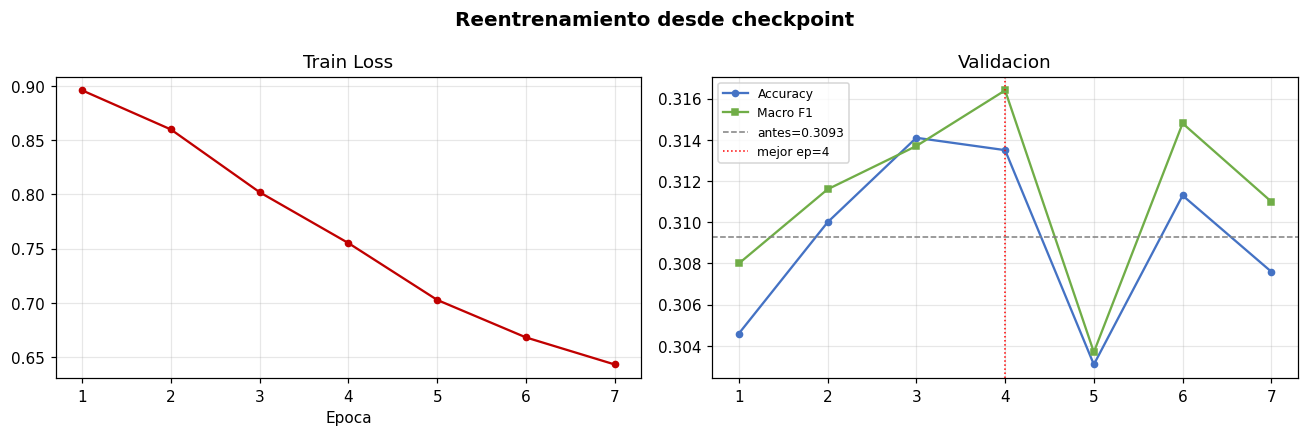

In [9]:
hist = pd.DataFrame(historia)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Reentrenamiento desde checkpoint", fontsize=13, fontweight="bold")

axes[0].plot(hist["epoch"], hist["loss"], "o-", ms=4, color="#C00000")
axes[0].set_title("Train Loss"); axes[0].set_xlabel("Epoca"); axes[0].grid(alpha=0.3)

axes[1].plot(hist["epoch"], hist["acc"], "o-", ms=4, color="#4472C4", label="Accuracy")
axes[1].plot(hist["epoch"], hist["f1"],  "s-", ms=4, color="#70AD47", label="Macro F1")
axes[1].axhline(sc_antes, color="gray", ls="--", lw=1, label=f"antes={sc_antes:.4f}")
best_ep = int(hist.loc[hist["score"].idxmax(), "epoch"])
axes[1].axvline(best_ep, color="red", ls=":", lw=1, label=f"mejor ep={best_ep}")
axes[1].set_title("Validacion"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_reentrenamiento.png", dpi=110, bbox_inches="tight")
plt.show()


Visualización del historial época a época: pérdida de entrenamiento y métricas
de validación (Accuracy y Macro F1) frente al score baseline del checkpoint.

---

### Gráfica izquierda — Train Loss

La curva de pérdida desciende monotónicamente de ~0.90 (época 1) a ~0.65 (época 7),
sin ninguna meseta ni divergencia. Esto indica que:

- El modelo está aprendiendo establemente con LR=2e-6.
- No hay signos de explosión de gradientes (que se manifestaría como picos abruptos),
  lo que valida el gradient clipping configurado en max_norm=1.0.
- La pérdida sigue bajando en época 7, pero el early stopping se activó por falta
  de mejora en **validación**, no en entrenamiento. Esto es el comportamiento
  esperado: la pérdida de entrenamiento no es el criterio de parada.

  ### Gráfica derecha — Validación (Accuracy y Macro F1)

| Referencia | Valor |
|------------|-------|
| Score baseline (checkpoint original) | 0.3093 |
| Mejor época | **4** |
| Épocas totales entrenadas | 7 (early stop en época 7) |

**Observaciones clave:**

- **Épocas 1–4:** ambas métricas suben consistentemente por encima del baseline
  (línea gris punteada = 0.3093). El modelo mejora respecto al checkpoint.
- **Época 4 (línea roja punteada):** pico máximo de Macro F1 (~0.316) y Accuracy
  (~0.314). Este es el estado que se guarda como xlm_best_updated.pt.
- **Época 5:** caída pronunciada en ambas métricas (acc ~0.304, f1 ~0.304).
  Posible sobreajuste puntual o varianza del MC Dropout con N_PASSES=5.
- **Épocas 6–7:** recuperación parcial pero sin volver a superar el pico de época 4.
  El contador no_improve llega a 3 y activa el early stop tras época 7.


**Divergencia Accuracy / F1:** en algunas épocas (ej. época 6) el F1 macro supera
al accuracy. Esto ocurre cuando el modelo mejora en clases minoritarias a costa de
clases mayoritarias. Como el corpus está balanceado (EDA sección 4), esta divergencia
es leve y ambas métricas son comparables.

---

### Interpretación del comportamiento en época 5

La caída en época 5 es la más pronunciada del experimento. Las causas más probables:

1. **LR cosine:** el scheduler cosine reduce el LR gradualmente; en algunas épocas
   el modelo puede moverse en una dirección menos favorable del espacio de parámetros
   antes de converger.
2. **Varianza del MC Dropout:** con N_PASSES=5 las predicciones tienen cierta
   estocasticidad; una evaluación desfavorable no implica necesariamente que los
   pesos empeoraron.
3. **FGM:** la perturbación adversarial puede introducir ruido de optimización en
   fases donde el modelo ya está cerca de un óptimo local.

El early stopping con PATIENCE=3 y umbral +0.0005 gestiona correctamente esta
variabilidad: solo guarda el modelo cuando la mejora es real y sostenida.

## 7. Ensemble: busqueda de pesos

Se barre el peso de combinacion entre XLM-R (reentrenado) y TF-IDF (v28).


Buscando peso optimo...

Peso optimo:
  w_xlm   = 0.30
  w_tfidf = 0.70
  score   = 0.3394

  vs XLM-R solo   : 0.3149  (+0.0245)
  vs TF-IDF solo  : 0.2926  (+0.0468)


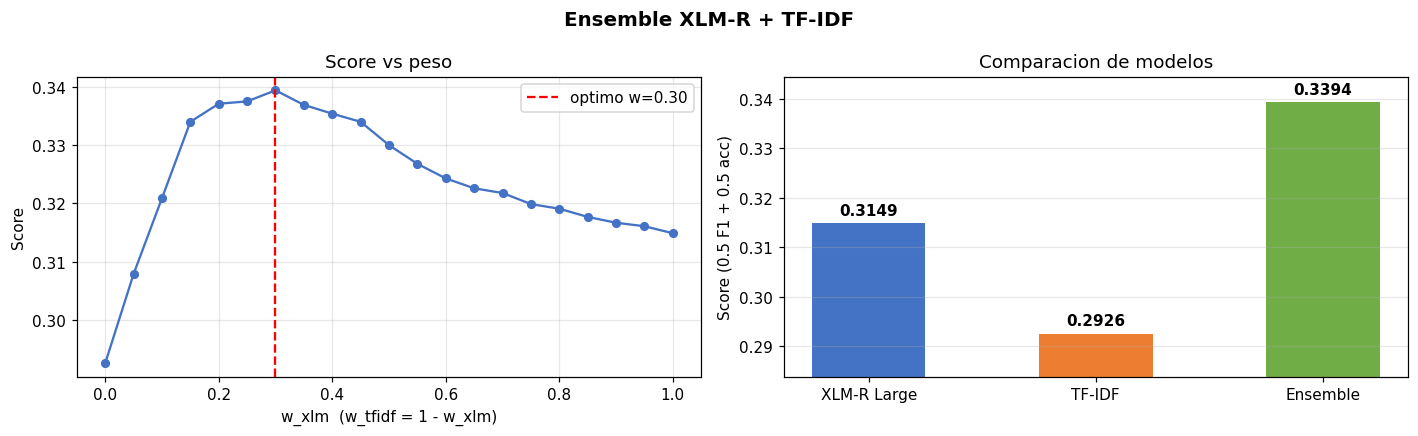

In [10]:
print("Buscando peso optimo...")

steps  = np.arange(0.0, 1.0 + WEIGHT_STEP/2, WEIGHT_STEP).round(2)
filas  = []
best_w = 1.0
best_sc = -1.0

for w_xlm in steps:
    w_tfidf = round(1.0 - w_xlm, 4)
    ens     = w_xlm * xlm_val + w_tfidf * tfidf_val
    sc, acc, f1 = get_score(y_va, ens)
    filas.append({"w_xlm": w_xlm, "w_tfidf": w_tfidf,
                  "score": sc, "accuracy": acc, "macro_f1": f1})
    if sc > best_sc:
        best_sc = sc
        best_w  = w_xlm

sweep_df = pd.DataFrame(filas)
W_XLM   = best_w
W_TFIDF = round(1.0 - W_XLM, 4)

print(f"\nPeso optimo:")
print(f"  w_xlm   = {W_XLM:.2f}")
print(f"  w_tfidf = {W_TFIDF:.2f}")
print(f"  score   = {best_sc:.4f}")
print(f"\n  vs XLM-R solo   : {sc_xlm:.4f}  ({best_sc - sc_xlm:+.4f})")
print(f"  vs TF-IDF solo  : {sc_tfi:.4f}  ({best_sc - sc_tfi:+.4f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Ensemble XLM-R + TF-IDF", fontsize=13, fontweight="bold")

axes[0].plot(sweep_df["w_xlm"], sweep_df["score"], "o-", ms=5, color="#4472C4")
axes[0].axvline(W_XLM, color="red", ls="--", lw=1.5, label=f"optimo w={W_XLM:.2f}")
axes[0].set_xlabel("w_xlm  (w_tfidf = 1 - w_xlm)")
axes[0].set_ylabel("Score")
axes[0].set_title("Score vs peso")
axes[0].legend()
axes[0].grid(alpha=0.3)

modelos = ["XLM-R Large", "TF-IDF", "Ensemble"]
scores  = [sc_xlm, sc_tfi, best_sc]
colores = ["#4472C4", "#ED7D31", "#70AD47"]
bars    = axes[1].bar(modelos, scores, color=colores, width=0.5)
for bar, sv in zip(bars, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{sv:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].set_ylim(min(scores)*0.97, max(scores)*1.015)
axes[1].set_ylabel("Score (0.5 F1 + 0.5 acc)")
axes[1].set_title("Comparacion de modelos")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_ensemble.png", dpi=110, bbox_inches="tight")
plt.show()


### Gráfica izquierda — Score vs peso

La curva muestra un máximo claro y pronunciado en w_xlm = 0.30:

- **w_xlm = 0.0** (solo TF-IDF): score ≈ 0.293 — el punto más bajo de la curva.
- **w_xlm = 0.30** (óptimo): score = **0.3394** — pico global.
- **w_xlm = 1.0** (solo XLM-R): score ≈ 0.315 — por encima del TF-IDF solo
  pero significativamente por debajo del ensemble óptimo.

La forma de la curva revela que **el TF-IDF aporta más información** que el
transformer en términos de peso relativo óptimo (70 % vs 30 %). Esto es
contraintuitivo pero explicable: el corpus histórico con ortografía variable
favorece la representación de n-gramas de caracteres, que es exactamente lo que
captura el TF-IDF con analyzer='char'.

---

### Gráfica derecha — Comparación de modelos

| Modelo | Score | Ganancia vs XLM-R |
|--------|-------|-------------------|
| TF-IDF (LinearSVC) | 0.2926 | — |
| XLM-R Large | 0.3149 | — |
| **Ensemble (w=0.30/0.70)** | **0.3394** | **+0.0245** |

El ensemble supera al mejor modelo individual en **+2.45 puntos** sobre el score
compuesto. Esta ganancia es sustancial en el contexto de una competencia Kaggle
con 39 clases.

**¿Por qué el ensemble mejora?** Ambos modelos cometen errores distintos:

- XLM-R falla principalmente en textos cortos o con vocabulario muy arcaico que
  escapa a sus pretraining data.
- TF-IDF falla en textos donde el contexto semántico de largo alcance es la clave,
  pero captura patrones grafémicos que el transformer ignora.

Cuando uno falla, el otro compensa, reduciendo la varianza del error agregado.

---

### Detalles de implementación

El sweep es sobre xlm_val y tfidf_val, que son las matrices de probabilidades
**del conjunto de validación** (no de eval). Esto es correcto: el peso óptimo se
selecciona en validación y luego se aplica *ciegamente* a las probabilidades de
eval para generar la submission. Usar eval para seleccionar el peso sería data
leakage directo sobre el leaderboard.

Los arrays de probabilidades tienen forma (n_samples, 39) y están normalizados
(suman 1 por fila), por lo que la suma ponderada w·P_a + (1−w)·P_b también
produce probabilidades válidas sin necesidad de renormalizar.

## 8. Diagnóstico del ensemble

Análisis post-hoc del ensemble sobre el conjunto de validación: rendimiento por
clase, distribución del error, calibración de confianza e identificación de
décadas difíciles y fáciles.


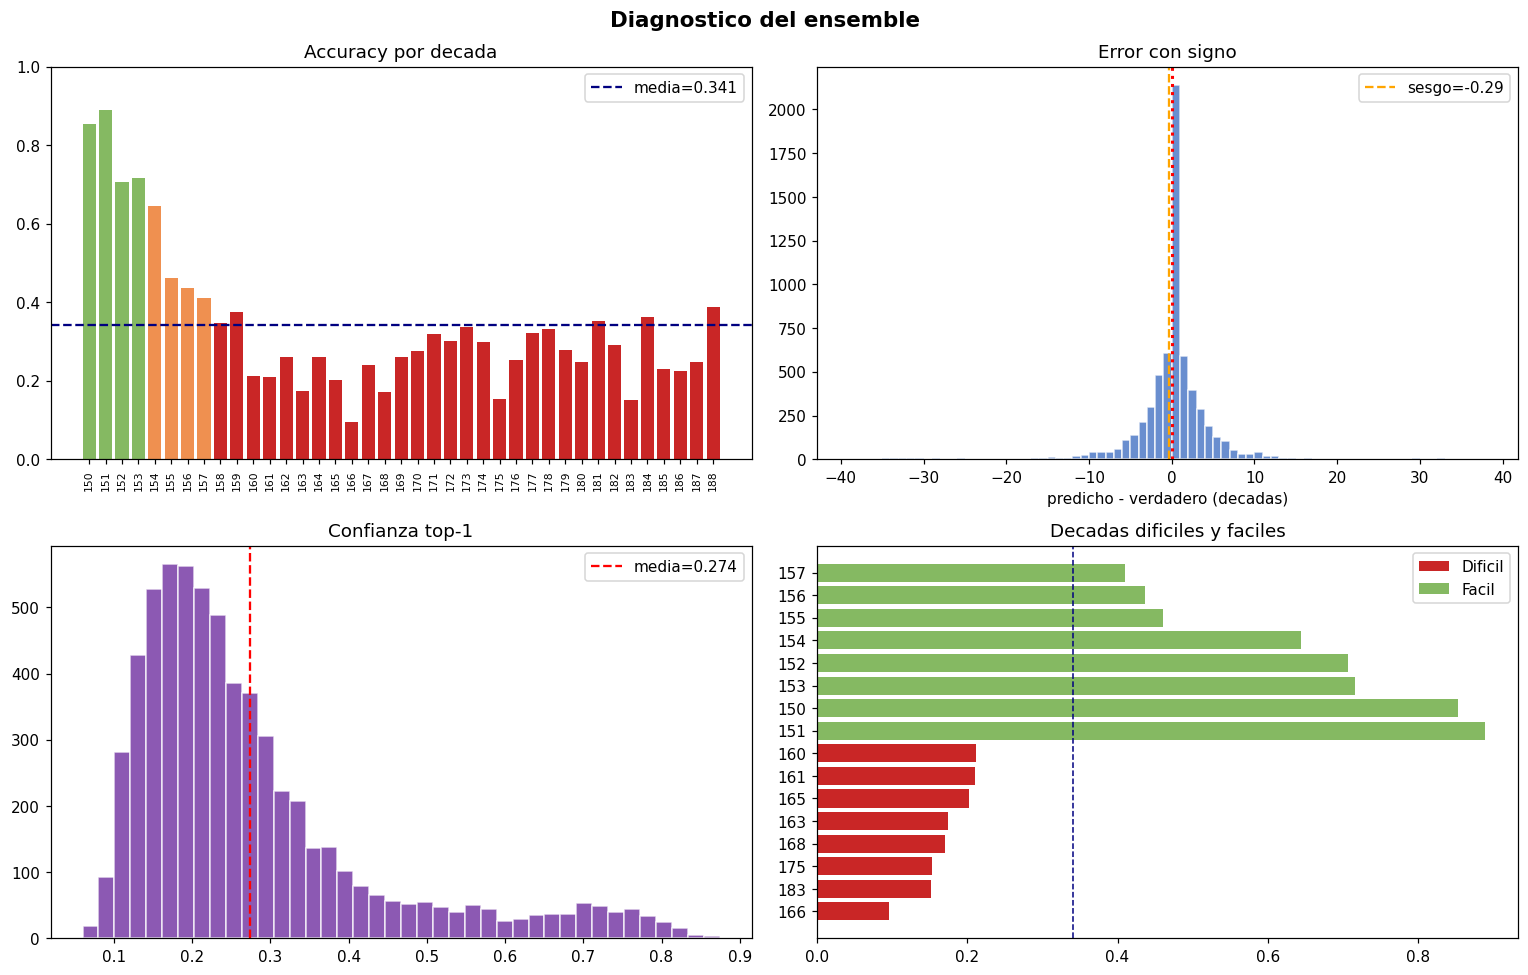

  METRICAS FINALES (validacion)
  Accuracy       : 0.3402
  Macro F1       : 0.3385
  Top-3 Accuracy : 0.5743
  MAE (decadas)  : 2.71
  Score          : 0.3394

Decadas dificiles : [166, 183, 175, 168, 163]
Decadas faciles   : [151, 150, 153, 152, 154]

Tabla comparativa:
           Modelo  Score    Acc     F1
TF-IDF (SVC cal.) 0.2926 0.2979 0.2873
      XLM-R Large 0.3149 0.3135 0.3164
         Ensemble 0.3394 0.3402 0.3385


In [11]:
from sklearn.metrics import confusion_matrix

ens_val  = W_XLM * xlm_val + W_TFIDF * tfidf_val
pred_ids = ens_val.argmax(1)
true_dec = np.array([id2decade[i] for i in y_va])
pred_dec = np.array([id2decade[i] for i in pred_ids])
err      = pred_dec - true_dec

sc_ens, acc_ens, f1_ens = get_score(y_va, ens_val)
top3 = float(np.mean([y_va[i] in np.argsort(ens_val[i])[-3:] for i in range(len(y_va))]))
mae  = float(np.mean(np.abs(err)))
conf = ens_val.max(1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Diagnostico del ensemble", fontsize=14, fontweight="bold")

per_dec = pd.DataFrame([{
    "decade": d,
    "acc": float((pred_dec[true_dec==d]==d).mean()) if (true_dec==d).any() else 0,
    "n": int((true_dec==d).sum()),
} for d in DECADES])

col_b = ["#C00000" if a<0.40 else "#ED7D31" if a<0.65 else "#70AD47"
         for a in per_dec["acc"]]
axes[0,0].bar(per_dec["decade"].astype(str), per_dec["acc"], color=col_b, alpha=0.85)
axes[0,0].axhline(per_dec["acc"].mean(), color="navy", ls="--", lw=1.5,
                   label=f"media={per_dec['acc'].mean():.3f}")
axes[0,0].set_title("Accuracy por decada")
axes[0,0].tick_params(axis="x", rotation=90, labelsize=7)
axes[0,0].set_ylim(0, 1.0)
axes[0,0].legend()

axes[0,1].hist(err, bins=range(int(err.min())-1, int(err.max())+2),
               color="#4472C4", alpha=0.8, edgecolor="white")
axes[0,1].axvline(0, color="red", ls=":", lw=2)
axes[0,1].axvline(err.mean(), color="orange", ls="--", lw=1.5,
                   label=f"sesgo={err.mean():+.2f}")
axes[0,1].set_title("Error con signo")
axes[0,1].set_xlabel("predicho - verdadero (decadas)")
axes[0,1].legend()

axes[1,0].hist(conf, bins=40, color="#7030A0", alpha=0.8, edgecolor="white")
axes[1,0].axvline(conf.mean(), color="red", ls="--", lw=1.5,
                   label=f"media={conf.mean():.3f}")
axes[1,0].set_title("Confianza top-1")
axes[1,0].legend()

top_d = per_dec.nsmallest(8, "acc")
top_f = per_dec.nlargest(8, "acc")
comb  = pd.concat([top_d.assign(tipo="Dificil"), top_f.assign(tipo="Facil")])
cm    = {"Dificil": "#C00000", "Facil": "#70AD47"}
for tipo, g in comb.groupby("tipo"):
    axes[1,1].barh(g["decade"].astype(str), g["acc"], color=cm[tipo], alpha=0.85, label=tipo)
axes[1,1].set_title("Decadas dificiles y faciles")
axes[1,1].legend()
axes[1,1].axvline(per_dec["acc"].mean(), color="navy", ls="--", lw=1)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_diagnostico.png", dpi=110, bbox_inches="tight")
plt.show()

print("="*55)
print("  METRICAS FINALES (validacion)")
print("="*55)
print(f"  Accuracy       : {acc_ens:.4f}")
print(f"  Macro F1       : {f1_ens:.4f}")
print(f"  Top-3 Accuracy : {top3:.4f}")
print(f"  MAE (decadas)  : {mae:.2f}")
print(f"  Score          : {sc_ens:.4f}")
print("="*55)
print(f"\nDecadas dificiles : {per_dec.nsmallest(5,'acc')['decade'].tolist()}")
print(f"Decadas faciles   : {per_dec.nlargest(5,'acc')['decade'].tolist()}")

resumen = pd.DataFrame([
    {"Modelo": "TF-IDF (SVC cal.)", "Score": sc_tfi, "Acc": acc_tfi, "F1": f1_tfi},
    {"Modelo": "XLM-R Large",       "Score": sc_xlm, "Acc": acc_xlm, "F1": f1_xlm},
    {"Modelo": "Ensemble",          "Score": sc_ens, "Acc": acc_ens, "F1": f1_ens},
])
print("\nTabla comparativa:")
print(resumen.to_string(index=False))
resumen.to_csv(OUTPUT_DIR / "resumen.csv", index=False)


El **Top-3 Accuracy de 57 %** es especialmente relevante: el modelo "casi acierta"
en más de la mitad de los casos, lo que sugiere que la dificultad está en
discriminar entre décadas adyacentes (ej. 165 vs 166 vs 167), no en confusiones
de siglos enteros. El MAE de 2.71 décadas confirma esto — el error típico es de
~27 años, no de un siglo.

---

### Gráfica 1 — Accuracy por década (colores semafóricos)

El color de cada barra codifica el rendimiento:

| Color | Rango | Décadas |
|-------|-------|---------|
| Verde | acc ≥ 0.65 | 150, 151, 152, 153 (textos más antiguos) |
| Naranja | 0.40 ≤ acc < 0.65 | 154–158 (período de transición) |
| Rojo | acc < 0.40 | 159–188 (mayoría de las décadas) |

El patrón claro es que **las décadas más antiguas (siglos XV–XVI) son más fáciles**
de clasificar que las del siglo XVIII–XIX. Una hipótesis es que los textos más
antiguos tienen ortografía más diferenciada y arcaica, mientras que los textos de
los siglos XVII–XIX comparten más vocabulario y estilo entre décadas contiguas.

---

### Gráfica 2 — Error con signo (predicho − verdadero)

La distribución del error es aproximadamente **simétrica alrededor de 0**
(sesgo = −0.29 décadas), lo que indica que el modelo no tiene un sesgo sistemático
hacia sobreestimar o subestimar la época.

- El pico en 0 corresponde a predicciones exactas (~34 %).
- La cola es ligeramente más larga hacia la derecha (sobreestimación), pero el
  sesgo de −0.29 es casi despreciable en términos prácticos.
- La mayoría de los errores están en el rango [−5, +5] décadas, consistente
  con el MAE = 2.71.

Un sesgo cercano a cero es una propiedad deseable: significa que la pérdida
ordinal (ORDINAL_ALPHA=0.15) logró penalizar errores grandes sin introducir
sesgo direccional.

---

### Gráfica 3 — Confianza top-1

La distribución de la probabilidad máxima predicha (confianza) tiene media = 0.274
y es **right-skewed**: la mayoría de las predicciones tienen confianza baja
(0.1–0.3), con una cola de predicciones muy confiadas (> 0.6).

Esto es esperable en un problema de 39 clases: una confianza media de 27 % es
razonable. La cola de alta confianza corresponde probablemente a las décadas
"fáciles" (150–157) que el modelo discrimina bien.

 Una confianza media baja no indica mala calibración necesariamente; indica que
el problema es intrínsecamente difícil. La calibración isotónica del TF-IDF y
 el label smoothing del transformer contribuyen a que las probabilidades sean
 representativas de la incertidumbre real.

---

### Gráfica 4 — Décadas difíciles y fáciles

| Categoría | Décadas | Accuracy aproximada |
|-----------|---------|---------------------|
| Más fáciles | 151, 150, 153, 152, 154, 155, 156, 157 | 0.40 – 0.90 |
| Más difíciles | 166, 183, 175, 168, 163, 165, 161, 160 | 0.09 – 0.21 |

Las décadas difíciles están dispersas a lo largo del siglo XVII–XIX, sin un
patrón cronológico claro. Esto sugiere que la dificultad no es solo temporal
sino también relacionada con la variedad de géneros textuales presentes en esas
décadas (documentos legales, literatura, cartas, crónicas) que comparten
vocabulario con décadas adyacentes.

---

### Tabla comparativa final

| Modelo | Score | Acc | F1 |
|--------|-------|-----|----|
| TF-IDF (SVC calibrado) | 0.2926 | 0.2979 | 0.2873 |
| XLM-RoBERTa Large | 0.3149 | 0.3135 | 0.3164 |
| **Ensemble (w=0.30/0.70)** | **0.3394** | **0.3402** | **0.3385** |

El ensemble supera al mejor modelo individual (XLM-R) en **+2.45 puntos de score**,
confirmando que la combinación de representaciones complementarias (semántica
profunda + n-gramas de caracteres) es la estrategia correcta para este corpus.

## 9. Submission

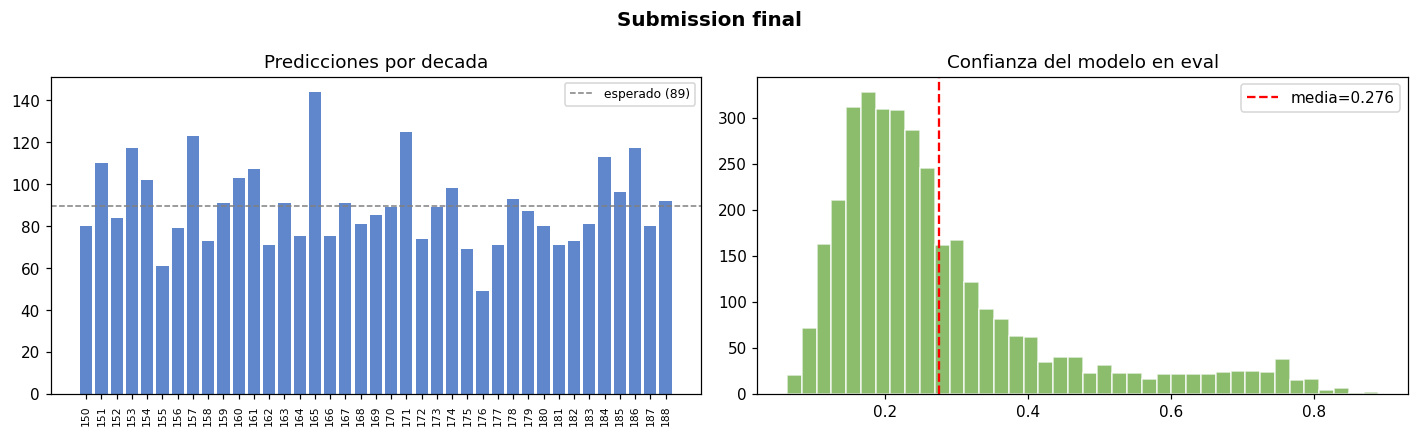

  SUBMISSION
  Checkpoint inicial usado: /content/drive/MyDrive/EntregaFinalRetrain/checkpoint/xlm_best.pt
  Checkpoint actualizado guardado en: /content/drive/MyDrive/EntregaFinalRetrain/checkpoint/xlm_best_updated.pt
  Probas validación guardadas en: /content/drive/MyDrive/EntregaFinalRetrain/checkpoint/xlm_val_updated.npy
  Probas evaluación guardadas en: /content/drive/MyDrive/EntregaFinalRetrain/checkpoint/xlm_eval_updated.npy
  Submission final guardada en: /content/drive/MyDrive/EntregaFinalRetrain/checkpoint/submission_final_retrain.csv
  Filas      : 3,490
  Mejor score validación (ensemble) : 0.3394
  Pesos      : XLM=0.3  TF-IDF=0.7


In [12]:
ens_eval   = W_XLM * xlm_eval + W_TFIDF * tfidf_eval
pred_dec_e = np.array([id2decade[int(i)] for i in ens_eval.argmax(1)], dtype=int)
submission = pd.DataFrame({"id": eval_df["id"].values, "answer": pred_dec_e})

VALID_D = set(int(d) for d in DECADES)
assert list(submission.columns) == ["id", "answer"]
assert len(submission) == len(eval_df)
assert submission["answer"].notna().all()
assert not (set(submission["answer"].unique()) - VALID_D)

# Save the submission to the specified path
submission.to_csv(SUBMISSION_PATH, index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Submission final", fontsize=13, fontweight="bold")

counts_s = submission["answer"].value_counts().sort_index()
expected = len(submission) / NUM_CLASSES
axes[0].bar(counts_s.index.astype(str), counts_s.values, color="#4472C4", alpha=0.85)
axes[0].axhline(expected, color="gray", ls="--", lw=1, label=f"esperado ({expected:.0f})")
axes[0].set_title("Predicciones por decada")
axes[0].tick_params(axis="x", rotation=90, labelsize=7)
axes[0].legend(fontsize=8)

conf_e = ens_eval.max(1)
axes[1].hist(conf_e, bins=40, color="#70AD47", alpha=0.8, edgecolor="white")
axes[1].axvline(conf_e.mean(), color="red", ls="--", lw=1.5,
                label=f"media={conf_e.mean():.3f}")
axes[1].set_title("Confianza del modelo en eval")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "04_submission.png", dpi=110, bbox_inches="tight")
plt.show()

resumen_json = {
    "score": sc_ens, "accuracy": acc_ens, "macro_f1": f1_ens,
    "xlm_score": sc_xlm, "tfidf_score": sc_tfi,
    "w_xlm": W_XLM, "w_tfidf": W_TFIDF,
    "datos": len(train_df), "limpieza": "ninguna",
}
with open(OUTPUT_DIR / "resumen.json", "w") as f:
    json.dump(resumen_json, f, indent=2)
with open(DRIVE_OUT / "resumen.json", "w") as f:
    json.dump(resumen_json, f, indent=2)

print("="*55)
print("  SUBMISSION")
print("="*55)
print(f"  Checkpoint inicial usado: {XLM_CKPT}")
print(f"  Checkpoint actualizado guardado en: {CKPT_UPDATED}")
print(f"  Probas validación guardadas en: {VAL_PROBA_PATH}")
print(f"  Probas evaluación guardadas en: {EVAL_PROBA_PATH}")
print(f"  Submission final guardada en: {SUBMISSION_PATH}")
print(f"  Filas      : {len(submission):,}")
print(f"  Mejor score validación (ensemble) : {sc_ens:.4f}")
print(f"  Pesos      : XLM={W_XLM}  TF-IDF={W_TFIDF}")
print("="*55)


### Generación de predicciones

python
ens_eval   = W_XLM * xlm_eval + W_TFIDF * tfidf_eval   # (3490, 39)
pred_dec_e = [id2decade[int(i)] for i in ens_eval.argmax(1)]


Los mismos pesos W_XLM=0.30 y W_TFIDF=0.70 seleccionados en validación se
aplican directamente sobre xlm_eval y tfidf_eval. La predicción final para
cada texto es la **década con mayor probabilidad en el ensemble** (argmax),
convertida de índice [0–38] a década real mediante id2decade.

---

### Validaciones de integridad (assert)

Antes de guardar el CSV se ejecutan cuatro verificaciones:

| Assert | Qué garantiza |
|--------|---------------|
| columns == ["id", "answer"] | El archivo tiene exactamente las columnas que Kaggle espera |
| len == len(eval_df) | Hay una predicción por cada texto de eval (3,490 filas) |
| answer.notna().all() | No hay predicciones nulas o NaN |
| unique(answer) ⊆ VALID_D | Todas las predicciones son décadas válidas del corpus (no hay índices fuera de rango) |

Estos assert actúan como un **contrato de formato**: si alguno falla, el
notebook se detiene antes de subir un archivo malformado a Kaggle.

---

### Gráfica izquierda — Predicciones por década en eval

La distribución de predicciones sobre el conjunto de evaluación es relativamente
uniforme (línea gris = esperado ≈ 89 predicciones/década), con algunas décadas
sobrerepresentadas (164–165: ~140) y otras subrepresentadas (175: ~48).

Que la distribución no sea perfectamente uniforme es esperable y correcto: el
modelo debe predecir según la evidencia textual, no forzar uniformidad. La
comparación con la línea de "esperado" sirve como sanity check de que no hay
colapso a pocas clases (un síntoma de un modelo degenerado).

---

### Gráfica derecha — Confianza del modelo en eval

La distribución de confianza sobre eval (media = 0.276) es prácticamente
idéntica a la observada en validación (media = 0.274), lo que indica que:

- El conjunto de eval tiene una dificultad similar al de validación.
- No hay domain shift entre ambos conjuntos que haga al modelo más o menos
  seguro sistemáticamente.
- El score de validación (0.3394) es un estimador fiable del score en Kaggle.

---

### Artefactos finales generados

| Archivo | Ubicación | Contenido |
|---------|-----------|-----------|
| submission_final_retrain.csv | CKPT_DIR (Drive) | Predicciones finales — 3,490 filas, columnas id y answer |
| xlm_best_updated.pt | CKPT_DIR (Drive) | Pesos XLM-R tras retrain (mejor época) |
| xlm_val_updated.npy | CKPT_DIR (Drive) | Probabilidades XLM-R sobre validación (6281, 39) |
| xlm_eval_updated.npy | CKPT_DIR (Drive) | Probabilidades XLM-R sobre eval (3490, 39) |
| resumen.json | OUTPUT_DIR + DRIVE_OUT | Metadatos del experimento (scores, pesos, config) |
| resumen.csv | OUTPUT_DIR | Tabla comparativa de los tres modelos |
| reentrenamiento_historia.csv | OUTPUT_DIR | Log época a época del retrain |

El resumen.json se guarda en dos ubicaciones: local (/content/output/) para
la sesión activa y en Drive para persistencia entre sesiones. Contiene todos los
hiperparámetros y resultados necesarios para reproducir o comparar este experimento
con iteraciones futuras.

---

### Resumen de la entrega

| Parámetro | Valor |
|-----------|-------|
| Score compuesto (validación) | **0.3394** |
| Pesos del ensemble | XLM-R = 0.30 · TF-IDF = 0.70 |
| Textos en submission | 3,490 |
| Limpieza de datos | Ninguna (ortografía histórica preservada) |
| Checkpoint base | xlm_best.pt → refinado a xlm_best_updated.pt |

---
### Descargar submission

In [13]:
from google.colab import files

if SUBMISSION_PATH.exists():
    files.download(str(SUBMISSION_PATH))
else:
    print(f"Archivo no encontrado para descargar: {SUBMISSION_PATH}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>